In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import sys
import numpy as np
import pickle

sys.path.append('D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin')
from models import *
from clients_datasets import *
from tqdm.notebook import tqdm
from utils import *
from AttFunc import *
from Fisher_LeNet import *

In [2]:
batch_size = 600
epochs = 30
NC = 10
dataset = 'svhn'

clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
clients_testloader = load_clients_testsets(dataset, NC, batch_size)

server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
client_level = 1
server_level = 6

criterion = torch.nn.CrossEntropyLoss()

Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat


In [3]:
acc0 = 95.48
att_type = 'sign'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Basic'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'svhn'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 6
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = 0.91
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id :
                benign_params = list(client.parameters())[:2]
                mal_params = perturbation(beta=beta, bp=benign_params, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: dat

In [3]:
acc0 = 95.48
att_type = 'sign'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Fisher'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'svhn'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 6
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = 0.91
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id :
                benign_params = list(client.parameters())[:2]
                fisher_matrix = {}
                for param_name, param in client.named_parameters():
                    if param_name == 'conv1.0.weight':
                        grad = param.grad.cpu().detach().numpy()
                        if param_name not in fisher_matrix:
                            fisher_matrix[param_name] = grad ** 2
                        else:
                            fisher_matrix[param_name] += grad ** 2
                    if param_name == 'conv1.0.bias':
                        grad = param.grad.cpu().detach().numpy()
                        if param_name not in fisher_matrix:
                            fisher_matrix[param_name] = grad ** 2
                        else:
                            fisher_matrix[param_name] += grad ** 2
                weight_positions = []
                bias_positions = []
                weight_positions.append(find_positions(fisher_matrix['conv1.0.weight'], 0.333))
                bias_positions.append(find_positions(fisher_matrix['conv1.0.bias'], 0.333))
                mal_params = fisher_perturbation(client_level, beta, benign_params, weight_positions, bias_positions, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: dat

In [4]:
acc0 = 95.48
att_type = 'sign'
ID_acc1 = []
clients_acc1 = []
iters = 10
mode = 'Taylor'

for iter in tqdm(range(iters), desc="Training", unit="iter"):
    # get ready
    batch_size = 600
    epochs = 30
    NC = 10
    dataset = 'svhn'
    clients_trainloader = load_clients_trainsets(dataset, NC, batch_size)
    clients_testloader = load_clients_testsets(dataset, NC, batch_size)
    server, server_opt, clients, clients_opts = set_model_and_opt(dataset, NC)
    client_level = 1
    server_level = 6
    criterion = torch.nn.CrossEntropyLoss()

    # train
    mal_client_id = iter
    server.train()
    for i in range(NC):
        clients[i].train()
    server.apply(init_weights)
    clients[0].apply(init_weights)
    last_trained_params = clients[0].state_dict()
    for epoch in range(epochs):
        beta = 0.91
        for idx, client in enumerate(clients):
            client.load_state_dict(last_trained_params)
            for j, data in enumerate(clients_trainloader[idx]):
                # training part
                images, labels = data
                images = images.cuda()
                labels = labels.cuda()
                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                clients_opts[idx].zero_grad()
                server_opt.zero_grad()
                loss = criterion(output, labels)
                loss.backward()
                clients_opts[idx].step()
                server_opt.step()
            # weight sharing
            last_trained_params = client.state_dict()
            # attack part
            if idx == mal_client_id:
                benign_params = list(client.parameters())[:2]
                Taylor_scores = {}
                for param_name, param in client.named_parameters():
                    if param.grad is not None:
                        Taylor_scores[param_name] = torch.abs(param * param.grad)
                weight_positions = []
                bias_positions = []
                weight_positions.append(find_positions(Taylor_scores['conv1.0.weight'].cpu().detach().numpy(), 0.333))
                bias_positions.append(find_positions(Taylor_scores['conv1.0.bias'].cpu().detach().numpy(), 0.333))
                mal_params = fisher_perturbation(client_level, beta, benign_params, weight_positions, bias_positions, type=att_type)
                last_trained_params['conv1.0.weight'] = mal_params[0]
                last_trained_params['conv1.0.bias'] = mal_params[1]
    for i in range(NC):
        clients[i].load_state_dict(last_trained_params)

    # test
    server.eval()
    for i in range(NC):
        clients[i].eval()
    with torch.no_grad():
        for idx, client in enumerate(clients):
            correct = 0
            total = 0
            acc1 = 0
            for data in clients_testloader[idx]:
                images, labels = data
                images, labels = images.cuda(), labels.cuda()

                smashed_data = client.forward(images, client_level=client_level)
                output = server.forward(smashed_data, server_level=server_level)
                _, pre = torch.max(output.data, 1)
                total += images.shape[0]
                correct += (pre == labels).sum().item()
            acc1 = 100 * correct / total
            clients_acc1.append(acc1)
    acc1 = np.mean(clients_acc1)
    ID_acc1.append(acc1)

print(ID_acc1)
np.save(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-{mode}.npy', ID_acc1)

Training:   0%|          | 0/10 [00:00<?, ?iter/s]

Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: data/test_32x32.mat
Using downloaded and verified file: data/train_32x32.mat
Using downloaded and verified file: dat

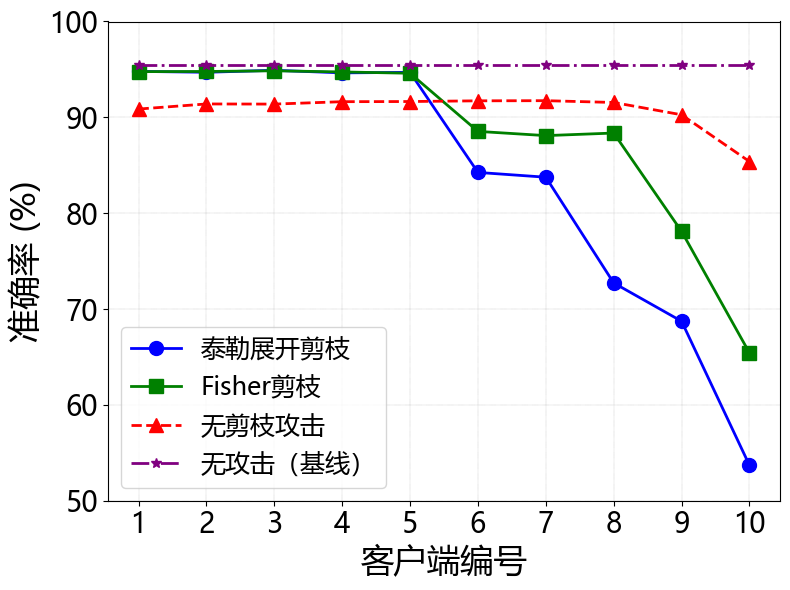

In [4]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

att_type = 'sign'
dataset = 'svhn'
baseline = [95.48] * 10
taylor = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Taylor.npy')
basic = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Basic.npy')
fisher = np.load(f'D:\\Program\\MyCode\\Round_robin_SL\\Round-Robin\\Evaluation2,3,4\\exper2-{dataset}-{att_type}-Fisher.npy')

basic = [i-3 for i in basic]
fisher[5:7] -=6
fisher[7] -= 4
fisher[8] -= 10
fisher[9:] -= 15
taylor[5:7] -=10
taylor[7:9] -=20
taylor[9:] -= 30

client_ids = list(range(1,11))

plt.figure(figsize=(8, 6))
plt.plot(client_ids, taylor, marker='o', markersize=10, label='泰勒展开剪枝', color='blue', linestyle='-', linewidth=2)
plt.plot(client_ids, fisher, marker='s', markersize=10, label='Fisher剪枝', color='green', linestyle='-', linewidth=2)
plt.plot(client_ids, basic, marker='^', markersize=10, label='无剪枝攻击', color='red', linestyle='--', linewidth=2)
plt.plot(client_ids, baseline, marker='*', markersize=7, label='无攻击（基线）', color='purple', linestyle='-.', linewidth=2)
plt.ylim(50, 100)
plt.xticks(client_ids,fontsize=20)  # Mark all client IDs
plt.yticks(fontsize=20)
plt.xlabel('客户端编号',fontsize=24)
plt.ylabel('准确率 (%)',fontsize=24)
# plt.title('Accuracy Comparison across Clients')
plt.legend(fontsize=18)

plt.grid(True, linestyle=':', linewidth=0.3, color='gray')
plt.tight_layout()
plt.show()